In [2]:
import pandas as pd

df = pd.read_csv("../data/synthetic_expenses.csv")
df.head()

,user_id,day,day_of_week,amount_spent_today,category,mood_while_spending,days_left_in_month,percent_budget_used_so_far,spending_trend,monthly_budget,overspending_risk
0,1,1,1,288.80,Other,Impulsive,29,1.16,0.00,25000,Medium
1,1,2,2,3282.21,Other,Stressed,28,14.28,0.00,25000,Medium
2,1,3,3,538.22,Other,Impulsive,27,16.44,0.00,25000,Medium
3,1,4,4,566.01,Other,Stressed,26,18.70,1173.35,25000,Medium
4,1,5,5,437.61,Shopping,Neutral,25,20.45,-1271.56,25000,Medium


In [3]:
df_encoded = pd.get_dummies(df, columns=["category", "mood_while_spending"], drop_first=False)
df_encoded.head()

,user_id,day,day_of_week,amount_spent_today,days_left_in_month,percent_budget_used_so_far,spending_trend,monthly_budget,overspending_risk,category_Entertainment,category_Food,category_Other,category_Shopping,category_Transport,mood_while_spending_Happy,mood_while_spending_Impulsive,mood_while_spending_Neutral,mood_while_spending_Stressed,mood_while_spending_Tired
0,1,1,1,288.80,29,1.16,0.00,25000,Medium,False,False,True,False,False,False,True,False,False,False
1,1,2,2,3282.21,28,14.28,0.00,25000,Medium,False,False,True,False,False,False,False,False,True,False
2,1,3,3,538.22,27,16.44,0.00,25000,Medium,False,False,True,False,False,False,True,False,False,False
3,1,4,4,566.01,26,18.70,1173.35,25000,Medium,False,False,True,False,False,False,False,False,True,False
4,1,5,5,437.61,25,20.45,-1271.56,25000,Medium,False,False,False,True,False,False,False,True,False,False


In [4]:
feature_cols = [
    "day_of_week",
    "amount_spent_today",
    "days_left_in_month",
    "percent_budget_used_so_far",
    "spending_trend",
] + [col for col in df_encoded.columns if col.startswith("category_") or col.startswith("mood_while_spending_")]

X = df_encoded[feature_cols]
y = df_encoded["overspending_risk"]

X.shape, y.shape

((15000, 15), (15000,))

In [5]:
y.value_counts()

overspending_risk
Low       7080
High      5880
Medium    2040
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((12000, 15), (3000, 15))

In [7]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_model.fit(X_train, y_train)

c:\Users\Kamran Tech\Desktop\Budget\SmartBudget\ml-service\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

              precision    recall  f1-score   support

        High       0.93      0.83      0.88      1176
         Low       0.92      0.79      0.85      1416
      Medium       0.40      0.72      0.51       408

    accuracy                           0.79      3000
   macro avg       0.75      0.78      0.75      3000
weighted avg       0.85      0.79      0.81      3000



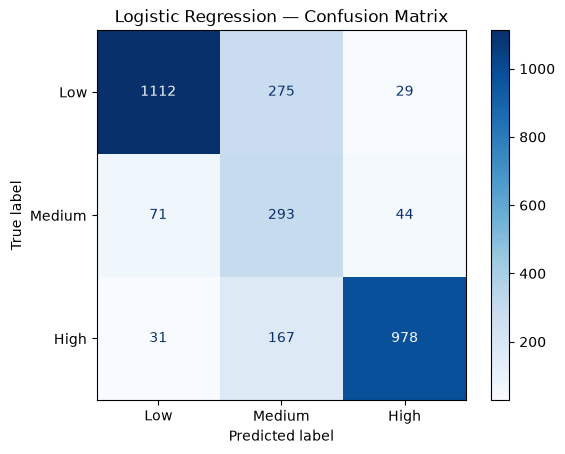

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = log_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

              precision    recall  f1-score   support

        High       0.94      0.68      0.79      1176
         Low       0.77      0.85      0.80      1416
      Medium       0.38      0.55      0.45       408

    accuracy                           0.74      3000
   macro avg       0.70      0.69      0.68      3000
weighted avg       0.78      0.74      0.75      3000



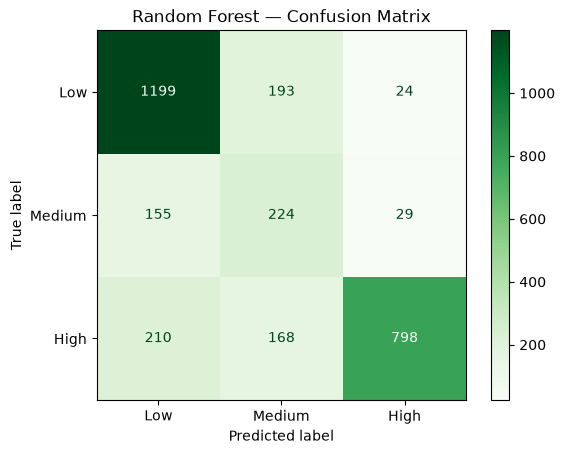

In [10]:
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["Low", "Medium", "High"])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Low", "Medium", "High"])
disp_rf.plot(cmap="Greens")
plt.title("Random Forest — Confusion Matrix")
plt.show()

In [11]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10)

percent_budget_used_so_far       0.562458
days_left_in_month               0.175330
amount_spent_today               0.091224
spending_trend                   0.086846
day_of_week                      0.030335
mood_while_spending_Impulsive    0.007015
category_Transport               0.005830
category_Food                    0.005690
category_Shopping                0.005669
mood_while_spending_Neutral      0.005610
dtype: float64

In [12]:
import joblib

joblib.dump(rf_model, "../models/risk_model.pkl")
joblib.dump(list(X.columns), "../models/feature_columns.pkl")

print("Model and feature columns saved.")

Model and feature columns saved.


In [13]:
sample_high_risk = X_test.iloc[[0]]  # grab any real test row to inspect
print(rf_model.predict_proba(sample_high_risk))
print(rf_model.classes_)

[[0.32051205 0.33771021 0.34177774]]
['High' 'Low' 'Medium']


In [14]:
import numpy as np

# check probability spread across the whole test set
probs = rf_model.predict_proba(X_test)
print("Min max-confidence:", probs.max(axis=1).min())
print("Max max-confidence:", probs.max(axis=1).max())
print("Mean max-confidence:", probs.max(axis=1).mean())

Min max-confidence: 0.3337569701177484
Max max-confidence: 0.9725677397330682
Mean max-confidence: 0.5604452458262111


In [15]:
import numpy as np

probs = rf_model.predict_proba(X_test)
print("Min max-confidence:", probs.max(axis=1).min())
print("Max max-confidence:", probs.max(axis=1).max())
print("Mean max-confidence:", probs.max(axis=1).mean())

Min max-confidence: 0.3337569701177484
Max max-confidence: 0.9725677397330682
Mean max-confidence: 0.5604452458262111


In [16]:
sample = X_test.iloc[[0]]
print(rf_model.predict_proba(sample))
print(rf_model.classes_)

[[0.32051205 0.33771021 0.34177774]]
['High' 'Low' 'Medium']


In [18]:
print(list(X.columns))

['day_of_week', 'amount_spent_today', 'days_left_in_month', 'percent_budget_used_so_far', 'spending_trend', 'category_Entertainment', 'category_Food', 'category_Other', 'category_Shopping', 'category_Transport', 'mood_while_spending_Happy', 'mood_while_spending_Impulsive', 'mood_while_spending_Neutral', 'mood_while_spending_Stressed', 'mood_while_spending_Tired']


In [19]:
import pandas as pd

CATEGORIES = ["Food", "Transport", "Shopping", "Entertainment", "Other"]
MOODS = ["Happy", "Neutral", "Stressed", "Impulsive", "Tired"]

def build_feature_row_debug(data, feature_columns):
    row = {
        "day_of_week": data["day_of_week"],
        "amount_spent_today": data["amount_spent_today"],
        "days_left_in_month": data["days_left_in_month"],
        "percent_budget_used_so_far": data["percent_budget_used_so_far"],
        "spending_trend": data["spending_trend"],
    }
    for cat in CATEGORIES:
        row[f"category_{cat}"] = 1 if data["category"] == cat else 0
    for mood in MOODS:
        row[f"mood_while_spending_{mood}"] = 1 if data["mood_while_spending"] == mood else 0

    df_row = pd.DataFrame([row])
    df_row = df_row.reindex(columns=feature_columns, fill_value=0)
    return df_row


high_risk_input = {
    "day_of_week": 6,
    "amount_spent_today": 2200,
    "days_left_in_month": 10,
    "percent_budget_used_so_far": 72.5,
    "spending_trend": 450,
    "category": "Shopping",
    "mood_while_spending": "Impulsive"
}

low_risk_input = {
    "day_of_week": 1,
    "amount_spent_today": 150,
    "days_left_in_month": 25,
    "percent_budget_used_so_far": 15,
    "spending_trend": -50,
    "category": "Food",
    "mood_while_spending": "Happy"
}

row_high = build_feature_row_debug(high_risk_input, list(X.columns))
row_low = build_feature_row_debug(low_risk_input, list(X.columns))

print("HIGH-RISK ROW:")
print(row_high)
print("\nLOW-RISK ROW:")
print(row_low)

print("\nHIGH-RISK PROBS:", rf_model.predict_proba(row_high))
print("LOW-RISK PROBS:", rf_model.predict_proba(row_low))
print("CLASSES:", rf_model.classes_)

HIGH-RISK ROW:
   day_of_week  amount_spent_today  days_left_in_month  \
0            6                2200                  10   

   percent_budget_used_so_far  spending_trend  category_Entertainment  \
0                        72.5             450                       0   

   category_Food  category_Other  category_Shopping  category_Transport  \
0              0               0                  1                   0   

   mood_while_spending_Happy  mood_while_spending_Impulsive  \
0                          0                              1   

   mood_while_spending_Neutral  mood_while_spending_Stressed  \
0                            0                             0   

   mood_while_spending_Tired  
0                          0  

LOW-RISK ROW:
   day_of_week  amount_spent_today  days_left_in_month  \
0            1                 150                  25   

   percent_budget_used_so_far  spending_trend  category_Entertainment  \
0                          15             -50  